## 0 · Instalación de dependencias

In [ ]:
%pip install openeo xarray geopandas rioxarray matplotlib contextily rasterio pyproj shapely --quiet

## 1 · Imports y funciones auxiliares

In [2]:
# Importación de librerías
import re
# Manejo de archivos y rutas
import os
import geopandas as gpd
# Manejo de fechas
import time
# Manejo de datos numéricos
import numpy as np
# Manejo de datos tabulares
import xarray as xr
# Lectura de rasters con soporte geoespacial
import rioxarray #Activar soporte geoespacial en xarray
# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# Mapas base
import contextily as ctx
# Lectura de rasters
import rasterio
# Geometría
from shapely.geometry import Polygon, box
# Proyecciones
from pyproj import Transformer
# OpenEO
import openeo
#Utilidad
from utils import make_polygon, bbox_from_polygon,plot_rgb_grid, plot_scl_map, download_date_rgb, download_date_scl, tif_to_scl, compute_scl_stats

## 2 · Configuración

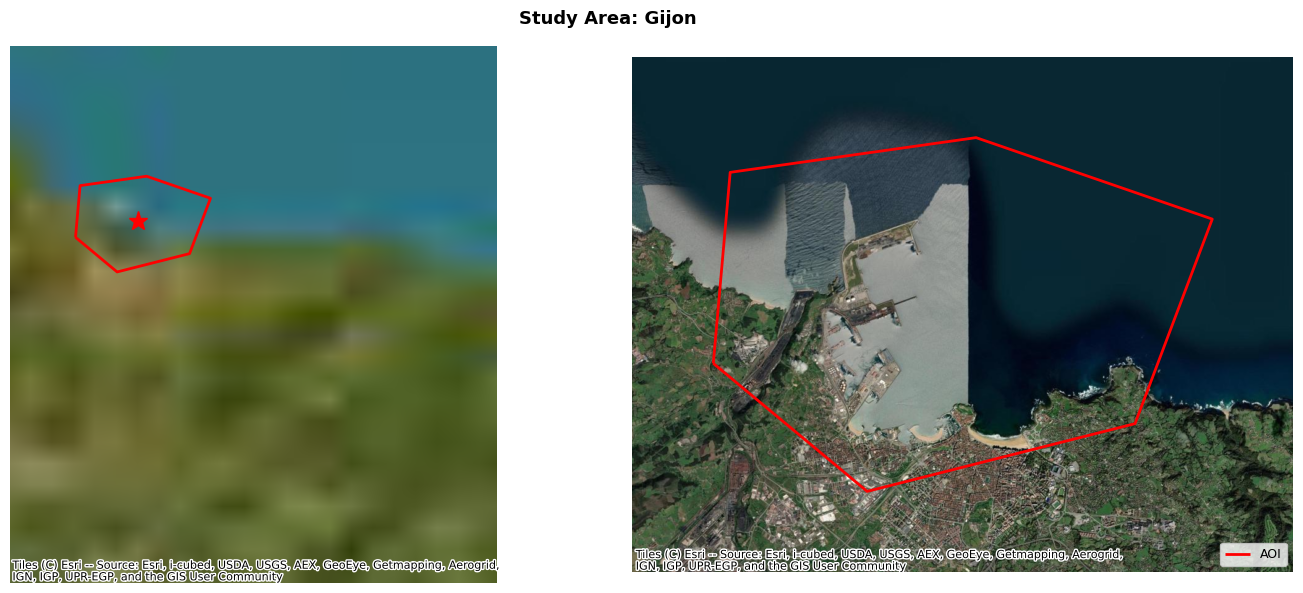

AOI bbox: {'west': -5.732727777777778, 'south': 43.53203333333333, 'east': -5.594119444444444, 'north': 43.603233333333336}
Fechas seleccionadas: 8


In [ ]:
# ── Identificador del sitio ───────────────────────────────────────────────────
site = "Gijon"

# ── Intervalo temporal ────────────────────────────────────────────────────────
# Rango amplio para que OpenEO encuentre imágenes disponibles
time_extent = ["2024-01-01", "2024-12-31"]

# ── Fechas a descargar ────────────────────────────────────────────────────────
# Puedes cambiarlas o añadir más. Formato: YYYY-MM-DD
# Tip: ejecuta primero la celda de exploración (sección 3) para ver fechas disponibles
selected_dates = [
    "2024-01-04",
    "2024-03-14",
    "2024-05-28",
    "2024-07-02",
    "2024-08-11",
    "2024-09-05",
    "2024-10-30",
    "2024-12-09",
]

# ── Umbral SCL ────────────────────────────────────────────────────────────────
# Fracción máxima de píxeles "malos" permitida para considerar una escena válida
# 0.20 = descarta si más del 20% de los píxeles son nubes/sombras/nieve
scl_bad_fraction = 0.20

# Clases SCL consideradas malas:
#   3  = sombra de nube
#   8  = nube media probabilidad
#   9  = nube alta probabilidad
#  10  = cirrus
#  11  = nieve/hielo
scl_bad_classes = [3, 8, 9, 10, 11]

# ── Directorios de salida ─────────────────────────────────────────────────────
dir_rgb = "tifs_rgb"     # GeoTIFFs RGB (B04, B03, B02)
dir_scl = "tifs_scl"     # GeoTIFFs SCL (banda de clasificación)

os.makedirs(dir_rgb, exist_ok=True)
os.makedirs(dir_scl, exist_ok=True)

# ── AOI — polígono de Gijón en DMS ────────────────────────────────────────────
aoi_dms = [
    '43°35\'46.50"N 5°43\'40.94"W',
    '43°36\'11.64"N 5°39\'35.03"W',
    '43°35\'12.64"N 5°35\'38.83"W',
    '43°32\'44.41"N 5°36\'56.10"W',
    '43°31\'55.32"N 5°41\'23.95"W',
    '43°33\'28.11"N 5°43\'57.82"W',
]

polygon = make_polygon(aoi_dms)
bbox    = bbox_from_polygon(polygon)
# CRS de referencia (WGS84)
crs = "EPSG:4326"

# CRS para visualización en Web Mercator
crs_web_mercator = "EPSG:3857"

# Creación del polígono del AOI a partir de las coordenadas DMS
polygon = make_polygon(aoi_dms)

# ════════════════════════════════════════════════════════════
# VISUALIZACIÓN CARTOGRÁFICA DEL AOI
# ════════════════════════════════════════════════════════════

# Se generan dos vistas:
# 1. Vista general de localizacion

# 2. Vista detallada sobre imagen satelital
fig, (ax_ov, ax_det) = plt.subplots(1, 2, figsize=(14, 6))

# Bounding box aproximada de Gijon

aoi_wm = gpd.GeoDataFrame(
    geometry=[box(-5.8, 43.3, -5.3, 43.7)], crs=crs
).to_crs(crs_web_mercator)

# Vista general

b = aoi_wm.total_bounds
ax_ov.set_xlim(b[0], b[2])
ax_ov.set_ylim(b[1], b[3])
ctx.add_basemap(ax_ov, crs=crs_web_mercator, source=ctx.providers.Esri.WorldImagery, zoom=6)

# Dibujo del polígono del AOI 
aoi_wm.boundary.plot(ax=ax_ov, color="red", linewidth=2)

# Marcador en el centroide
centroid = aoi_wm.geometry.iloc[0].centroid
ax_ov.plot(centroid.x, centroid.y, marker="*", color="red", markersize=14, zorder=5)
ax_ov.set_axis_off()

# Vista detallada
BUFFER = 2500
b = aoi_wm.total_bounds
ax_det.set_xlim(
    b[0] - BUFFER, 
    b[2] + BUFFER
)
ax_det.set_ylim(
    b[1] - BUFFER,
    b[3] + BUFFER
)
ctx.add_basemap(
    ax_det, crs=crs_web_mercator,
    source=ctx.providers.Esri.WorldImagery,
    zoom=13)
aoi_wm.boundary.plot(
    ax=ax_det,
    color="red",
    linewidth=2,
    label="AOI"
    )
ax_det.legend(
    loc="lower right",
    fontsize=9
)
fig.suptitle(
    f"Study Area: {site}",
    fontsize=13,
    fontweight="bold"
)
ax_det.set_axis_off()

fig.suptitle(f"Study Area: {site}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


polygon = make_polygon(aoi_dms)
bbox    = bbox_from_polygon(polygon)

print(f"AOI bbox: {bbox}")
print(f"Fechas seleccionadas: {len(selected_dates)}")


## 3 · Conexión a OpenEO y exploración de fechas disponibles

In [4]:
# Conectar al backend de Copernicus Dataspace
conn = openeo.connect("https://openeo.dataspace.copernicus.eu/")

# Autenticación OIDC (abre el navegador la primera vez; luego usa tokens cacheados)
conn.authenticate_oidc()

print("Conectado:", conn.describe_account()["name"])

Authenticated using refresh token.
Conectado: Jorge Alias


In [5]:
# ── Consulta lazy del cubo completo ──────────────────────────────────────────
# Esto NO descarga nada, solo define el proceso graph en el backend

cube_explore = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=time_extent,
    bands=["B04"],          # una banda basta para listar fechas
    max_cloud_cover=100,    # sin filtro de nubes aquí (lo hacemos con SCL)
)

# Obtener etiquetas temporales disponibles (pequeña query al backend)
all_dates = cube_explore.dimension_labels("t").execute()

print(f"Fechas disponibles en el periodo {time_extent[0]} → {time_extent[1]}:")
print(f"  Total: {len(all_dates)}")
for d in all_dates:
    marker = " seleccionada" if d in selected_dates else ""
    print(f"  {d}{marker}")

Fechas disponibles en el periodo 2024-01-01 → 2024-12-31:
  Total: 145
  Mon, 01 Jan 2024 00:00:00 GMT
  Thu, 04 Jan 2024 00:00:00 GMT
  Sat, 06 Jan 2024 00:00:00 GMT
  Tue, 09 Jan 2024 00:00:00 GMT
  Thu, 11 Jan 2024 00:00:00 GMT
  Sun, 14 Jan 2024 00:00:00 GMT
  Tue, 16 Jan 2024 00:00:00 GMT
  Fri, 19 Jan 2024 00:00:00 GMT
  Sun, 21 Jan 2024 00:00:00 GMT
  Wed, 24 Jan 2024 00:00:00 GMT
  Fri, 26 Jan 2024 00:00:00 GMT
  Mon, 29 Jan 2024 00:00:00 GMT
  Wed, 31 Jan 2024 00:00:00 GMT
  Sat, 03 Feb 2024 00:00:00 GMT
  Mon, 05 Feb 2024 00:00:00 GMT
  Thu, 08 Feb 2024 00:00:00 GMT
  Sat, 10 Feb 2024 00:00:00 GMT
  Tue, 13 Feb 2024 00:00:00 GMT
  Thu, 15 Feb 2024 00:00:00 GMT
  Sun, 18 Feb 2024 00:00:00 GMT
  Tue, 20 Feb 2024 00:00:00 GMT
  Fri, 23 Feb 2024 00:00:00 GMT
  Sun, 25 Feb 2024 00:00:00 GMT
  Wed, 28 Feb 2024 00:00:00 GMT
  Fri, 01 Mar 2024 00:00:00 GMT
  Mon, 04 Mar 2024 00:00:00 GMT
  Wed, 06 Mar 2024 00:00:00 GMT
  Sat, 09 Mar 2024 00:00:00 GMT
  Mon, 11 Mar 2024 00:00:00 GMT
 

## 4 · Descarga de imágenes RGB

Se lanza un batch job por cada fecha. Si el archivo ya existe, se salta (útil para retomar descargas interrumpidas).

In [7]:
# ── Lanzar descargas ──────────────────────────────────────────────────────────
print(f"Descargando {len(selected_dates)} fechas RGB...\n")

# Descarga secuencial (puedes paralelizar con multiprocessing o concurrent.futures si quieres)
results_rgb = {}
for date in selected_dates:
    print(f"→ {date}")
    results_rgb[date] = download_date_rgb(conn, date, bbox, dir_rgb)

print("\n── Resumen RGB ──")
for date, status in results_rgb.items():
    print(f"  {date}: {status}")

Descargando 8 fechas RGB...

→ 2024-01-04
0:00:00 Job 'j-260611100507427da7540c59560c312c': send 'start'
0:00:02 Job 'j-260611100507427da7540c59560c312c': created (progress 0%)
0:00:07 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:00:13 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:00:21 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:00:31 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:00:44 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:00:59 Job 'j-260611100507427da7540c59560c312c': queued (progress 0%)
0:01:19 Job 'j-260611100507427da7540c59560c312c': finished (progress 100%)
   2024-01-04 → tifs_rgb\rgb_2024-01-04.tif
→ 2024-03-14
0:00:00 Job 'j-260611100631402da512a3c002a9e145': send 'start'
0:00:02 Job 'j-260611100631402da512a3c002a9e145': queued (progress 0%)
0:00:07 Job 'j-260611100631402da512a3c002a9e145': queued (progress 0%)
0:00:14 Job 'j-260611100631402da512a3c002a9e145': queued (pr

## 5 · Descarga de SCL (Scene Classification Layer)

In [8]:

# Solo descargar SCL para fechas donde RGB fue exitoso
dates_with_rgb = [
    d for d, s in results_rgb.items()
    if s in ("ok", "skipped")
]

print(f"Descargando SCL para {len(dates_with_rgb)} fechas...\n")

# Descarga secuencial (puedes paralelizar con multiprocessing o concurrent.futures si quieres)
results_scl = {}
for date in dates_with_rgb:
    print(f"→ {date}")
    results_scl[date] = download_date_scl(conn, date, bbox, dir_scl)

print("\n── Resumen SCL ──")
for date, status in results_scl.items():
    print(f"  {date}: {status}")

Descargando SCL para 8 fechas...

→ 2024-01-04
0:00:00 Job 'j-2606111023484ea5a379ba89b9416852': send 'start'
0:00:02 Job 'j-2606111023484ea5a379ba89b9416852': queued (progress 0%)
0:00:08 Job 'j-2606111023484ea5a379ba89b9416852': queued (progress 0%)
0:00:14 Job 'j-2606111023484ea5a379ba89b9416852': queued (progress 0%)
0:00:22 Job 'j-2606111023484ea5a379ba89b9416852': queued (progress 0%)
0:00:32 Job 'j-2606111023484ea5a379ba89b9416852': running (progress N/A)
0:00:44 Job 'j-2606111023484ea5a379ba89b9416852': running (progress N/A)
0:01:00 Job 'j-2606111023484ea5a379ba89b9416852': running (progress N/A)
0:01:19 Job 'j-2606111023484ea5a379ba89b9416852': running (progress N/A)
0:01:43 Job 'j-2606111023484ea5a379ba89b9416852': finished (progress 100%)
   2024-01-04 → tifs_scl\scl_2024-01-04.tif
→ 2024-03-14
0:00:00 Job 'j-2606111025354905a5d31bd2a559bbc7': send 'start'
0:00:02 Job 'j-2606111025354905a5d31bd2a559bbc7': queued (progress 0%)
0:00:07 Job 'j-2606111025354905a5d31bd2a559bbc7'

## 6 · Grid completo — todas las fechas descargadas

Se muestran todas las imágenes RGB. El título de cada panel incluye la fecha.

Mostrando 8 imágenes


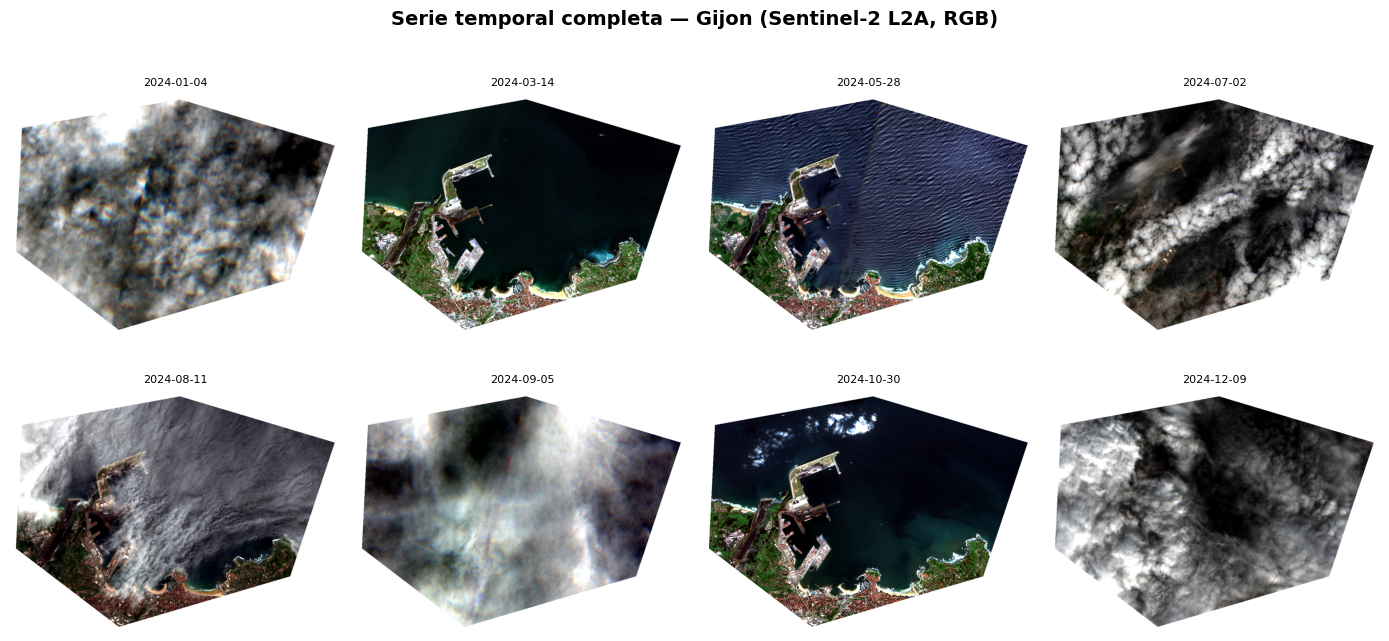

In [ ]:

# ── Grid completo ─────────────────────────────────────────────────────────────
valid_rgb_dates = [
    d for d in selected_dates
    if os.path.exists(os.path.join(dir_rgb, f"rgb_{d}.tif"))
]

print(f"Mostrando {len(valid_rgb_dates)} imágenes")

plot_rgb_grid(
    dates=valid_rgb_dates,
    rgb_dir=dir_rgb,
    polygon=polygon,  
    title=f"Serie temporal completa — {site} (Sentinel-2 L2A, RGB)",
    cols=4,
)

## 7 · Cálculo del filtro SCL

Para cada escena se calcula qué fracción de sus píxeles cae en una clase "mala" (nubes, sombras, nieve). Las escenas por encima del umbral se descartan.

In [20]:

# Mapa de colores oficial ESA para SCL
scl_colors = {
    0: ("No data", "#000000"),
    1: ("Saturado/Defectuoso", "#ff0000"),
    2: ("Sombra topográfica", "#2f2f2f"),
    3: ("Sombra de nube", "#646464"),
    4: ("Vegetación", "#00a000"),
    5: ("No vegetación", "#ffe65a"),
    6: ("Agua", "#0000ff"),
    7: ("Sin clasificar", "#808080"),
    8: ("Nube media prob.", "#c0c0c0"),
    9: ("Nube alta prob.", "#ffffff"),
    10: ("Cirrus", "#87ceeb"),
    11: ("Nieve/Hielo", "#e0ffff"),
}

# ── Calcular estadísticas para todas las fechas con SCL ───────────────────────
scl_stats = {}

# Solo procesar fechas que tengan RGB válido (y por tanto SCL descargado)
for date in valid_rgb_dates:
    scl_path = os.path.join(dir_scl, f"scl_{date}.tif")
    scl_arr = tif_to_scl(scl_path)
    if scl_arr is None:
        print(f"    {date}: SCL no disponible")
        continue
    stats = compute_scl_stats(scl_arr, scl_bad_classes)
    scl_stats[date] = stats
    verdict = "VÁLIDA" if stats["bad_fraction"] <= scl_bad_fraction else " DESCARTADA"
    print(f"  {date}  {stats['bad_pct']:5.1f}% malos  {verdict}")


# ── Clasificar fechas ─────────────────────────────────────────────────────────
dates_valid     = [d for d in valid_rgb_dates if d in scl_stats and scl_stats[d]["bad_fraction"] <= scl_bad_fraction]
dates_discarded = [d for d in valid_rgb_dates if d in scl_stats and scl_stats[d]["bad_fraction"] >  scl_bad_fraction]
dates_no_scl    = [d for d in valid_rgb_dates if d not in scl_stats]

print(f"\n── Resultado (umbral SCL = {scl_bad_fraction*100:.0f}%) ──")
print(f"  Válidas:    {len(dates_valid)}")
print(f"  Descartadas:{len(dates_discarded)}")
print(f"  Sin SCL:    {len(dates_no_scl)}")

  2024-01-04   99.9% malos   DESCARTADA
  2024-03-14    0.0% malos  VÁLIDA
  2024-05-28    8.8% malos  VÁLIDA
  2024-07-02   74.7% malos   DESCARTADA
  2024-08-11    5.9% malos  VÁLIDA
  2024-09-05   99.9% malos   DESCARTADA
  2024-10-30    0.6% malos  VÁLIDA
  2024-12-09   76.8% malos   DESCARTADA

── Resultado (umbral SCL = 20%) ──
  Válidas:    4
  Descartadas:4
  Sin SCL:    0


## 8 · Visualización del filtro — barras de calidad SCL

Gráfico resumen con la fracción de píxeles malos por escena.

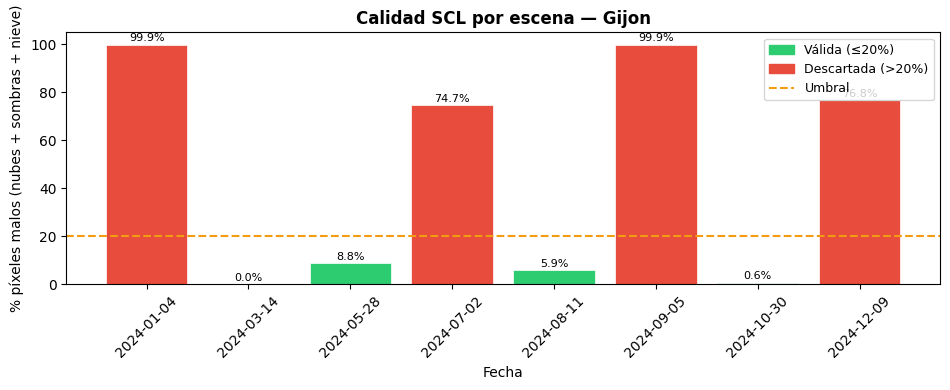

💾 Guardado: scl_quality_bars.png


In [ ]:
# ── Visualización de calidad SCL ─────────────────────────────────────────────
if scl_stats:
    dates_sorted = sorted(scl_stats.keys())
    bad_pcts     = [scl_stats[d]["bad_pct"] for d in dates_sorted]
    colors       = ["#2ecc71" if scl_stats[d]["bad_fraction"] <= scl_bad_fraction else "#e74c3c"
                    for d in dates_sorted]

    fig, ax = plt.subplots(figsize=(max(8, len(dates_sorted) * 1.2), 4))

    bars = ax.bar(dates_sorted, bad_pcts, color=colors, edgecolor="white", linewidth=0.5)

    # Línea de umbral
    ax.axhline(
        scl_bad_fraction * 100,
        color="#f39c12", linestyle="--", linewidth=1.5,
        label=f"Umbral ({scl_bad_fraction*100:.0f}%)"
    )

    # Etiquetas encima de cada barra
    for bar, pct in zip(bars, bad_pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{pct:.1f}%",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_xlabel("Fecha", fontsize=10)
    ax.set_ylabel("% píxeles malos (nubes + sombras + nieve)", fontsize=10)
    ax.set_title(f"Calidad SCL por escena — {site   }", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 105)
    ax.tick_params(axis="x", rotation=45)

    # Leyenda
    valid_patch    = mpatches.Patch(color="#2ecc71", label=f"Válida (≤{scl_bad_fraction*100:.0f}%)")
    discard_patch  = mpatches.Patch(color="#e74c3c", label=f"Descartada (>{scl_bad_fraction*100:.0f}%)")
    ax.legend(handles=[valid_patch, discard_patch,
                        plt.Line2D([0],[0], color="#f39c12", linestyle="--", label=f"Umbral")],
              loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig("scl_quality_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Guardado: scl_quality_bars.png")

## 9 · Grid de imágenes válidas

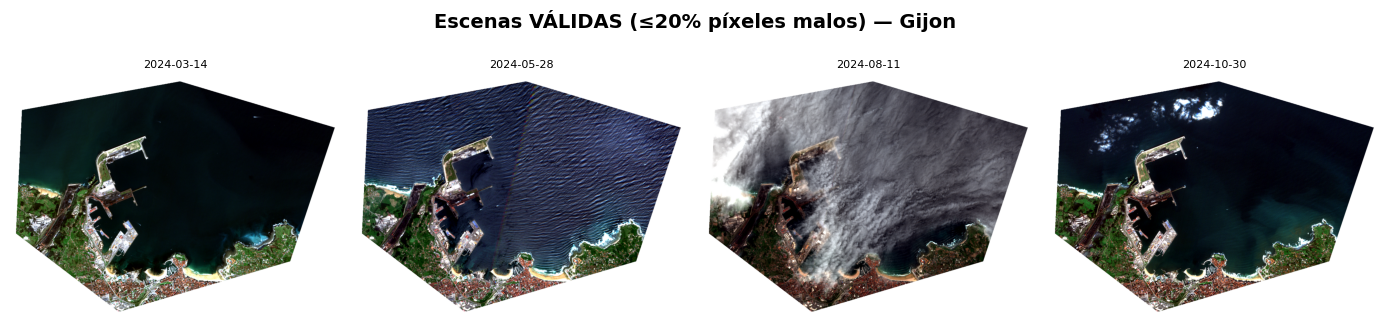

In [12]:
# ── Grid solo con fechas válidas según SCL ─────────────────────────────────
plot_rgb_grid(
        dates=dates_valid,
        rgb_dir=dir_rgb,
        polygon=polygon,
        title=f"Escenas VÁLIDAS (≤{scl_bad_fraction*100:.0f}% píxeles malos) — {site}",
        cols=4,)

## 10 · Grid de imágenes descartadas

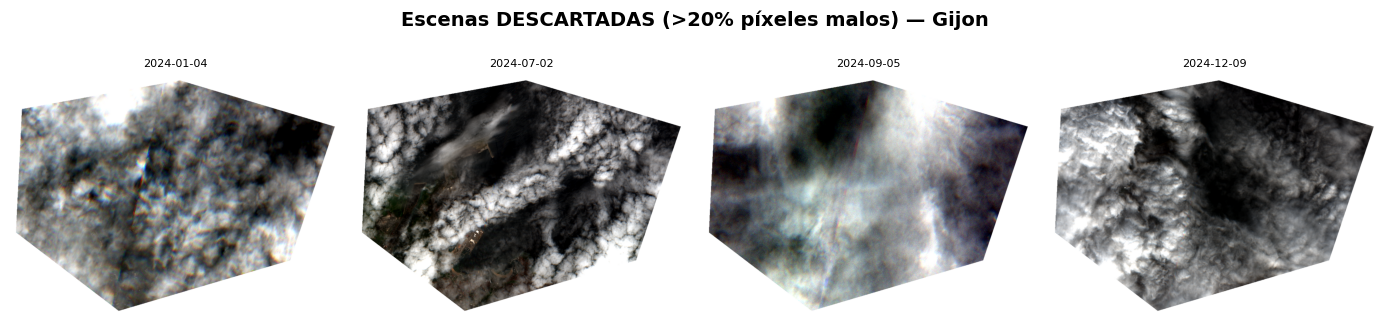

In [15]:
# ── Grid solo con fechas descartadas según SCL ───────────────────────────────
if dates_discarded:
    subtitles_discarded = {
        d: f"{scl_stats[d]['bad_pct']:.1f}% malos"
        for d in dates_discarded if d in scl_stats
    }
    highlights_discarded = {d: "#e74c3c" for d in dates_discarded}

    plot_rgb_grid(
        dates=dates_discarded,
        rgb_dir=dir_rgb,
        polygon=polygon,
        title=f"Escenas DESCARTADAS (>{scl_bad_fraction*100:.0f}% píxeles malos) — {site}",
        cols=4,
    )
else:
    print("Todas las escenas pasaron el filtro SCL. 🎉")

## 11 · (Opcional) Visualizar el mapa SCL de una escena

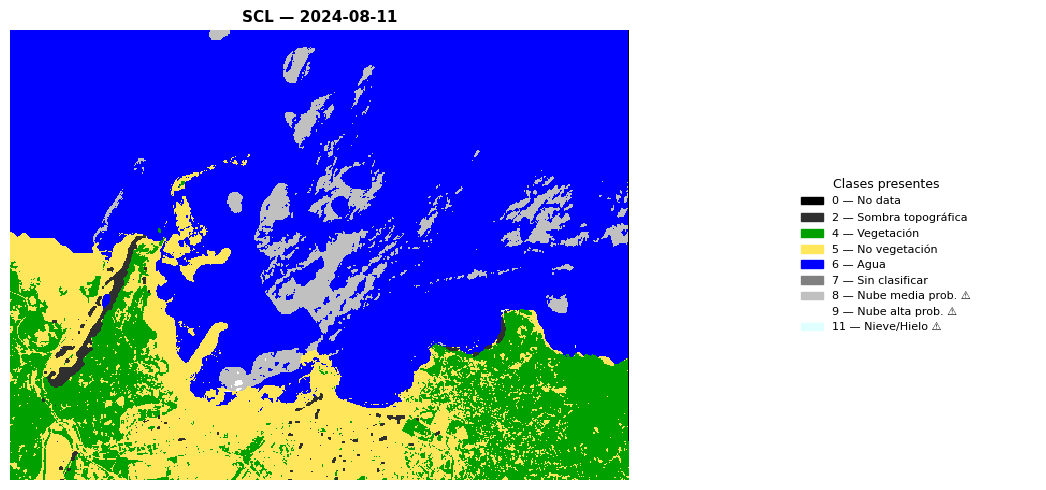

In [29]:
# ── Cambiar la fecha aquí para inspeccionar cualquier escena ──────────────────
# Pon una fecha de selected_dates que tenga SCL descargado
inspect_date = selected_dates[4]   # ← cambia esto
    
plot_scl_map(inspect_date, dir_scl, scl_colors=scl_colors, scl_bad_classes=scl_bad_classes, scl_stats=scl_stats, scl_max_bad_fraction=scl_bad_fraction)